<a href="https://colab.research.google.com/github/NavyaGambirapuram/AI_CRM_HCP/blob/main/BrainTumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import os
import cv2

create zipfile of braintumor then copy all the images folder into the zipfile

In [ ]:
from zipfile import ZipFile
with ZipFile("/content/Braintumor.zip","r") as zip:
    zip.extractall("/content")

In [ ]:
#Training  and Testing data
train_path="/content/Braintumor/Training"
test_path="/content/Braintumor/Testing"

In [ ]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['glioma', 'pitutary', 'notumor', 'meningioma']
['glioma', 'pitutary', 'notumor', 'meningioma']


Image Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen=ImageDataGenerator(rescale=1./255)


In [ ]:
#Load the testing dataset
test_generator=test_datagen.flow_from_directory(test_path,target_size=(224,224),
                                                batch_size=32,class_mode="categorical",shuffle=False)

Found 1200 images belonging to 4 classes.


Training Data Generator with Augmentation

In [ ]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 rotation_range=20,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)

In [ ]:
train_generator=train_datagen.flow_from_directory(train_path,target_size=(224,224),
                                                batch_size=32,class_mode="categorical")

Found 1200 images belonging to 4 classes.


In [ ]:
#check the classes
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pitutary': 3}


 :Building of CNN :

In [ ]:
import tensorflow as tf
from PIL import Image,ImageEnhance
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout


In [ ]:

model=Sequential()

model.add(Conv2D(filters=32,kernel_size=(3,3),
                 activation="relu",input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

#second Convolutional Layer
model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

#Third Convolutional Layer
model.add(Conv2D(filters=128,kernel_size=(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128,activation="relu"))

#Dropout Layer
model.add(Dropout(0.5))
#Dense Output Layer
model.add(Dense(4,activation="softmax"))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

: Complie and Train the Model :

In [ ]:
from IPython.core import history
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
history=model.fit(train_generator,validation_data=test_generator,epochs=20)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 248s 5s/step - accuracy: 0.2633 - loss: 1.4395 - val_accuracy: 0.2875 - val_loss: 1.3077
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.4567 - loss: 1.1488 - val_accuracy: 0.5300 - val_loss: 1.1100
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 183s 5s/step - accuracy: 0.5558 - loss: 0.9971 - val_accuracy: 0.6025 - val_loss: 1.0068
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.5642 - loss: 0.9883 - val_accuracy: 0.3950 - val_loss: 1.7106
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.5892 - loss: 0.9666 - val_accuracy: 0.6200 - val_loss: 0.9219
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.6292 - loss: 0.8923 - val_accuracy: 0.6250 - val_loss: 0.8944
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.5825 - loss: 0.9320 - val_accuracy: 0.5100 - val_loss: 1.1729
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 183s 5s/step - accuracy: 0.6408 - loss: 0.8948 - val_accuracy: 0.6167 - v

: Model Evalution :

In [ ]:
test_loss,test_acc=model.evaluate(test_generator)
print("Test Loss :" , test_loss)
print("Test Accuracy :" , test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6408 - loss: 0.9511
Test Loss : 0.9510988593101501
Test Accuracy : 0.64083331823349


: Plot the Training and Validation Accuracy :

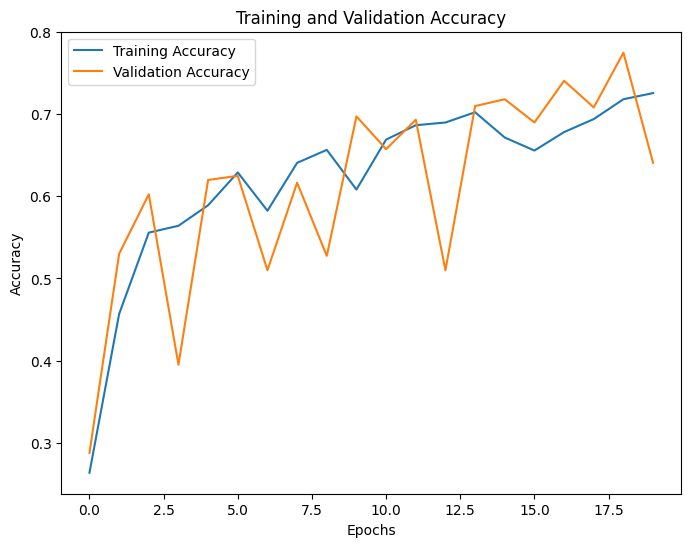

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

: Plot Training and Validation Loss :

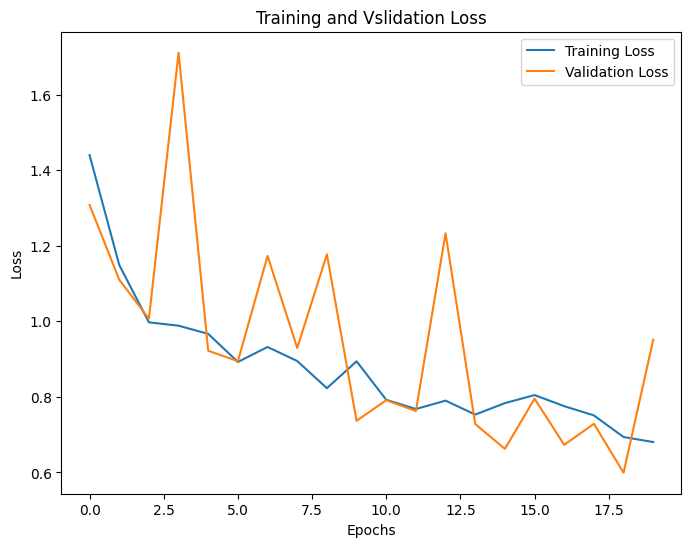

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Training and Vslidation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

: Generate Predictions :

In [ ]:
predictions=model.predict(test_generator)
y_pred=np.argmax(predictions,axis=1)
y_true=test_generator.classes
print(y_true[:10])
print(y_pred[:10])

38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step
[0 0 0 0 0 0 0 0 0 0]
[2 0 0 0 0 0 0 0 0 1]


: Confusion matrix :

[[181  51  47  21]
 [ 42 142  74  42]
 [  1   2 293   4]
 [  7   4 136 153]]


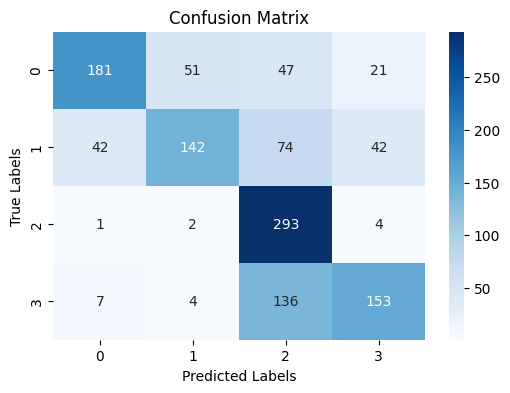

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_true,y_pred)
print (cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt="d",cmap="Blues")

xticklabels=test_generator.class_indices.keys()

yticklabels=test_generator.class_indices.keys()

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

: Classification Report :

In [ ]:
from sklearn.metrics import classification_report
report=classification_report(y_true,y_pred,target_names=test_generator.class_indices.keys())
print(report)

              precision    recall  f1-score   support

      glioma       0.78      0.60      0.68       300
  meningioma       0.71      0.47      0.57       300
     notumor       0.53      0.98      0.69       300
    pitutary       0.70      0.51      0.59       300

    accuracy                           0.64      1200
   macro avg       0.68      0.64      0.63      1200
weighted avg       0.68      0.64      0.63      1200



In [ ]:
model.save("brain_tumor_CNN_model.h5")
#model.save('my_model.keras')

: Predict a New MRI image :

Saving gl-0015.jpg to gl-0015 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
predicted class : glioma


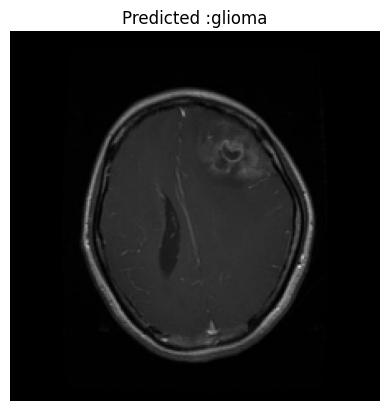

In [ ]:
from google.colab import files
uploaded=files.upload()
categories=["glioma","meningioma","notumor","pituitary"]
img =cv2.imread("/content/Braintumor/Testing/glioma/gl-0004.jpg")
img =cv2.resize(img,(224,224))
img= img/255.0
img=np.expand_dims(img,axis=0)
pred=model.predict(img)
pred_class=np.argmax(pred)

print("predicted class :",categories[pred_class])
plt.imshow(img[0])
plt.title("Predicted :" +categories[pred_class])
plt.axis("off")
plt.show()